# Resume Screening and Role Matching using NLP
### Enterprise-Style AI-Powered Applicant Tracking System (ATS) Prototype

| | |
|---|---|
| **Project Title** | Resume Screening and Role Matching using NLP |
| **Company** | TalentBridge Solutions Pvt. Ltd. |
| **Author** | Sahil Uniyal |
| **Project Code** | 24CRD02503 |
| **Technology Stack** | Python, Pandas, NumPy, Scikit-learn, NLTK, TF-IDF, Cosine Similarity, Matplotlib, Seaborn, Streamlit |

---

#### Introduction

TalentBridge Solutions receives thousands of resumes for a wide range of technology and business roles. Reviewing every resume manually is slow, inconsistent, and prone to recruiter bias. This capstone project builds an **end-to-end, NLP-driven Applicant Tracking System (ATS)** that automatically validates resume data, engineers business-relevant candidate features, matches each candidate to the most suitable enterprise role using **TF-IDF and Cosine Similarity**, and produces a **Hybrid ATS Fit Score** that blends skill match, experience, project relevance, education, ATS readiness, and leadership signals.

This notebook reproduces the exact logic implemented in the project's production modules — `src/ats_pipeline.py` and `src/role_catalog.py` — and walks through the complete workflow from raw data to final, recruiter-ready candidate rankings.


## 2. Business Problem

**Why is resume screening difficult?**
Recruiters at TalentBridge Solutions must evaluate thousands of resumes against multiple open roles. Each resume is unstructured, inconsistently formatted, and uses varied terminology for the same skill (e.g. "ML" vs "Machine Learning"). Manually reading every resume does not scale, and different recruiters often reach different shortlisting decisions for the same candidate.

**Limitations of traditional ATS systems**
- Most legacy ATS tools rely on **exact keyword matching**, so a resume that says "predictive modelling" instead of "machine learning" can be unfairly rejected.
- They cannot capture **context** — a candidate who merely mentions a skill in passing is scored the same as one with deep, demonstrated expertise.
- They rarely combine skills, experience, leadership, and ATS readiness into a **single, explainable fit score**.
- They offer little support for **comparing a candidate across multiple possible roles** at once.

**Why NLP helps**
Natural Language Processing techniques such as **TF-IDF vectorization** and **Cosine Similarity** let the system understand resumes as weighted collections of meaningful terms rather than rigid keyword lists. This captures contextual overlap between a candidate's experience/project narrative and a role's requirements, even when exact wording differs.

**Business objectives**
- Automate first-pass resume screening to reduce recruiter workload.
- Objectively match candidates to the enterprise role they fit best.
- Produce a transparent, multi-factor **Final Fit Score** (skills, experience, projects, education, ATS readiness, leadership).
- Classify candidates into actionable recommendation categories.
- Power an interactive recruiter dashboard for search, comparison, and analytics.


## 3. Dataset Overview

Two source files are used in this project:

- **`parsed_resumes.csv`** — the primary structured dataset containing **5,000 candidate profiles** with **34 columns**: candidate identifiers, primary domain/role, education, raw skills/tools/soft-skills text, free-text experience/project/achievement summaries, a set of binary experience flags (management, cloud, ML, mentoring, etc.), and resume-quality metrics (`resume_length_words`, `keyword_density_score`, `profile_completeness_score`).
- **`Data Definition (3).xlsx`** — a data dictionary describing every column in `parsed_resumes.csv`, used to understand each field before preprocessing.

Important features used throughout the pipeline include `technical_skills_raw`, `tools_platforms_raw`, `soft_skills_raw`, `experience_summary`, `project_summary`, `key_achievements`, `years_experience`, `highest_education`, `institution_tier`, the binary experience flags, and the resume-quality scores.

All file paths below are **relative to the project folder**, so the notebook runs unchanged on any machine.


In [1]:
import pandas as pd
import os

# Relative paths (no hardcoded machine-specific locations)
DATA_DIR = '.'
csv_path = os.path.join(DATA_DIR, 'parsed_resumes.csv')
excel_path = os.path.join(DATA_DIR, 'Data Definition (3).xlsx')

resume_df = pd.read_csv(csv_path)
data_definition_df = pd.read_excel(excel_path)

print('Resume dataset loaded from:', csv_path)
print('Data dictionary loaded from:', excel_path)


Resume dataset loaded from: ./parsed_resumes.csv
Data dictionary loaded from: ./Data Definition (3).xlsx


In [2]:
resume_df.head()

,candidate_id,resume_file_name,candidate_name,primary_domain,primary_role,years_experience,highest_education,education_field,institution_tier,technical_skills_raw,...,enterprise_systems_experience_flag,offshore_onsite_model_experience_flag,multi_vendor_coordination_flag,process_compliance_experience_flag,documentation_heavy_role_flag,mentoring_experience_flag,stakeholder_management_experience_flag,resume_length_words,keyword_density_score,profile_completeness_score
0,CND_100001,DataAnalyst_1.pdf,Candidate_1,Data Science,Data Analyst,7,LLM,Mathematics,Tier-1,"Machine Learning, Power BI, Pandas, Python",...,1,1,1,1,0,1,1,56,0.74,0.61
1,CND_100002,profile_2.pdf,Candidate_2,IT,Senior Software Engineer,10,Masters,Computer Science,Tier-2,"Kubernetes, Git, Docker, Python",...,1,1,1,1,1,1,1,54,0.89,0.89
2,CND_100003,Legal_candidate_3.pdf,Candidate_3,Legal,Compliance Officer,7,LLM,Law,Tier-1,"Due Diligence, Legal Research, Compliance, Con...",...,1,1,1,1,1,1,1,57,0.40,0.56
3,CND_100004,IT_candidate_4.pdf,Candidate_4,IT,Senior Software Engineer,9,LLM,Computer Science,Tier-1,"Kubernetes, AWS, SQL, Docker",...,1,1,1,1,1,1,1,55,0.74,0.89
4,CND_100005,IT_candidate_5.pdf,Candidate_5,IT,Software Engineer,9,Masters,Information Technology,Tier-1,"Java, Kubernetes, Git, AWS",...,1,1,1,1,1,1,1,51,0.58,0.59


In [3]:
print('Shape (rows, columns):', resume_df.shape)

Shape (rows, columns): (5000, 34)


In [4]:
resume_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 34 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   candidate_id                            5000 non-null   str    
 1   resume_file_name                        5000 non-null   str    
 2   candidate_name                          5000 non-null   str    
 3   primary_domain                          5000 non-null   str    
 4   primary_role                            5000 non-null   str    
 5   years_experience                        5000 non-null   int64  
 6   highest_education                       4730 non-null   str    
 7   education_field                         4763 non-null   str    
 8   institution_tier                        5000 non-null   str    
 9   technical_skills_raw                    5000 non-null   str    
 10  tools_platforms_raw                     5000 non-null   str    
 11  so

**Observations**
- The dataset contains **5,000 candidate records** across **34 columns**, matching the data dictionary.
- Columns fall into four natural groups: identifiers/metadata (`candidate_id`, `resume_file_name`, `candidate_name`), categorical attributes (`primary_domain`, `primary_role`, `highest_education`, `institution_tier`), free-text fields (`technical_skills_raw`, `experience_summary`, `project_summary`, `key_achievements`), and numeric/binary indicators (`years_experience`, 16 experience flags, and 3 resume-quality scores).
- Several text columns can contain missing values, which is addressed in the Data Validation section next.


In [5]:
data_definition_df.head(15)

,Column Name,Description,Business Meaning
0,candidate_id,Unique identifier for each candidate,"Used for tracking, indexing and mapping candid..."
1,resume_file_name,Original filename of the resume,Mimics real-world ATS uploads; helps identify ...
2,candidate_name,Placeholder name for candidate,Used for personalization and referencing (not ...
3,primary_domain,"Domain/category (IT, Data Science, HR, Legal, ...",Helps understand candidate’s functional backgr...
4,primary_role,Candidate’s stated role or designation,Strong indicator of job match relevance
5,years_experience,Total years of professional experience,Key signal of seniority and suitability for ro...
6,highest_education,"Highest qualification (e.g., Bachelors, Master...",Determines academic suitability or minimum qua...
7,education_field,"Field of study (CS, Statistics, Law, HR, etc.)",Helps assess domain relevance for technical or...
8,institution_tier,Category of educational institution (Tier-1/2/3),Used by many enterprises as a proxy for baseli...
9,technical_skills_raw,Raw extracted technical skills (with noise),Requires NLP cleaning; primary indicator of ma...


**Observation:** The data dictionary confirms the intended meaning and data type of every column in `parsed_resumes.csv`, which guided the cleaning rules and feature engineering logic implemented in `src/ats_pipeline.py`.

## 4. Data Validation

Before any scoring can be trusted, the raw data must be validated. The `load_and_validate_data()` function in `src/ats_pipeline.py` performs the following checks, each of which exists for a clear business reason:

- **Missing Value Check** — free-text fields (skills, summaries, achievements) are filled with empty strings so downstream text-cleaning and TF-IDF steps never fail on `NaN`; numeric quality scores are imputed with the column mean so a single missing score does not distort an otherwise complete profile.
- **Duplicate Check** — duplicate `candidate_id` values would cause the same person to be counted, scored, and shortlisted twice, inflating recruiter workload and skewing analytics.
- **Data Type Check** — ensures fields like `resume_length_words` are integers and quality scores are floats, which is required for the scaling and arithmetic used in feature engineering.
- **Resume Length Validation** — extremely short resumes (`resume_length_words`) are a proxy for incomplete or low-effort applications and are penalised in the `resume_quality_score`.
- **Keyword Density Validation** — `keyword_density_score` reflects how well a resume is optimised for ATS keyword scanning; missing values are imputed rather than dropped so no candidate is unfairly excluded.
- **Profile Completeness Validation** — `profile_completeness_score` captures how many expected resume sections are filled in; this feeds directly into both the `resume_quality_score` and `ats_readiness_score`.

We now call the actual pipeline function to perform these checks on the real dataset.


In [6]:
import sys
sys.path.append('.')  # ensure the local src/ package is importable

from src.ats_pipeline import (
    load_and_validate_data, engineer_features, build_role_descriptions,
    compute_similarity_scores, compute_role_fit, classify_candidates,
    clean_text, normalize_skills, generate_corpus
)
from src.role_catalog import ROLE_DEFINITIONS

df, validation_report, original_df = load_and_validate_data(csv_path)
validation_report


{'rows': 5000,
 'columns': 34,
 'duplicates_candidate_id': 0,
 'missing_values': 0,
 'missing_by_column': {'candidate_id': 0,
  'resume_file_name': 0,
  'candidate_name': 0,
  'primary_domain': 0,
  'primary_role': 0,
  'years_experience': 0,
  'highest_education': 0,
  'education_field': 0,
  'institution_tier': 0,
  'technical_skills_raw': 0,
  'tools_platforms_raw': 0,
  'soft_skills_raw': 0,
  'experience_summary': 0,
  'project_summary': 0,
  'key_achievements': 0,
  'management_experience_flag': 0,
  'people_management_flag': 0,
  'project_management_experience_flag': 0,
  'agile_scrum_experience_flag': 0,
  'client_facing_experience_flag': 0,
  'delivery_lead_experience_flag': 0,
  'cloud_experience_flag': 0,
  'ml_experience_flag': 0,
  'compliance_experience_flag': 0,
  'enterprise_systems_experience_flag': 0,
  'offshore_onsite_model_experience_flag': 0,
  'multi_vendor_coordination_flag': 0,
  'process_compliance_experience_flag': 0,
  'documentation_heavy_role_flag': 0,
  '

**Observation:** The validation report above is produced directly by the production pipeline. It summarises the row/column counts, the number of duplicate `candidate_id` values found, the total missing values before imputation, and a column-wise breakdown of missingness — confirming the dataset is now clean and consistent enough for feature engineering.

In [7]:
print('Duplicate candidate_id rows:', validation_report['duplicates_candidate_id'])
print('Total missing values (raw data):', validation_report['missing_values'])
print('Data types after validation:')
df.dtypes[['resume_length_words', 'keyword_density_score', 'profile_completeness_score']]


Duplicate candidate_id rows: 0
Total missing values (raw data): 0
Data types after validation:


resume_length_words             int64
keyword_density_score         float64
profile_completeness_score    float64
dtype: object

**Observation:** `resume_length_words` is confirmed as an integer column, while `keyword_density_score` and `profile_completeness_score` are floats — exactly as required by the scoring formulas used later in the pipeline.

## 5. Exploratory Data Analysis (EDA)

With validated data in hand, we explore the distribution of key candidate attributes. Each chart is followed by the business insight it reveals. Feature-derived charts (Resume Quality, ATS Readiness, Candidate Quality Index) use the engineered scores computed in Section 6, so we run feature engineering first and then return to plotting.


In [8]:
df = engineer_features(df)
df[['resume_quality_score', 'ats_readiness_score', 'candidate_quality_index']].describe()


,resume_quality_score,ats_readiness_score,candidate_quality_index
count,5000.000000,5000.00000,5000.000000
mean,72.261357,66.45570,43.848592
std,8.542805,10.92307,15.946631
min,51.933333,40.50000,5.909967
25%,65.779167,58.50000,30.974158
50%,72.250000,66.50000,44.360420
75%,78.700000,74.50000,56.422743
max,93.150000,92.50000,86.009945


**Observation:** Feature engineering has been applied so that the EDA charts below can use the same engineered scores that drive the final ATS ranking.

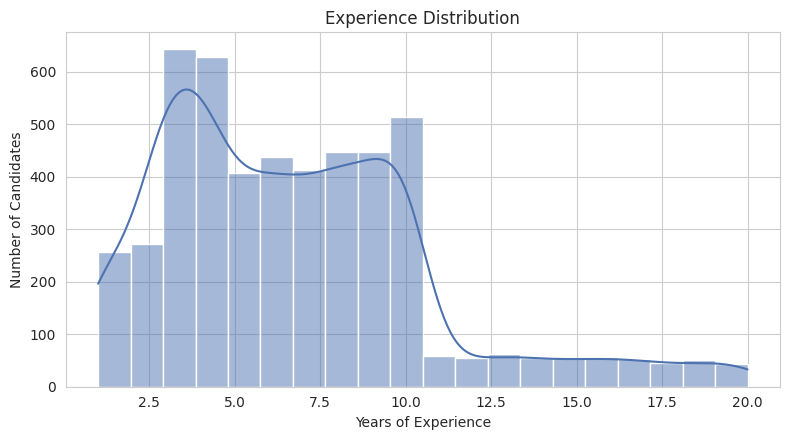

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

plt.figure()
sns.histplot(df['years_experience'], bins=20, color='#4C72B0', kde=True)
plt.title('Experience Distribution')
plt.xlabel('Years of Experience')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()


**What it shows:** The spread of `years_experience` across all 5,000 candidates.
**Business insight:** The candidate pool spans entry-level to senior professionals, which is why the pipeline defines experience buckets (Entry, Mid, Senior, Lead, Architect) rather than treating experience as a single uniform group — recruiters need role-appropriate seniority filtering.


/tmp/ipykernel_614/1770690509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='primary_role', order=order, palette='viridis')


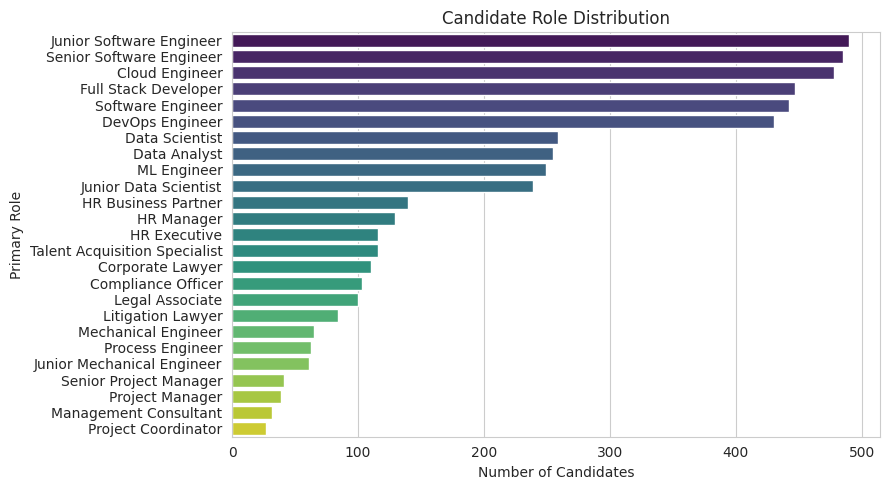

In [10]:
plt.figure(figsize=(9, 5))
order = df['primary_role'].value_counts().index
sns.countplot(data=df, y='primary_role', order=order, palette='viridis')
plt.title('Candidate Role Distribution')
plt.xlabel('Number of Candidates')
plt.ylabel('Primary Role')
plt.tight_layout()
plt.show()


**What it shows:** How candidates are distributed across the `primary_role` values declared on their resumes.
**Business insight:** Some roles attract far more applicants than others, helping TalentBridge anticipate which talent pools are oversubscribed and which roles may need wider sourcing efforts.


/tmp/ipykernel_614/886393934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='highest_education', order=edu_order, palette='mako')


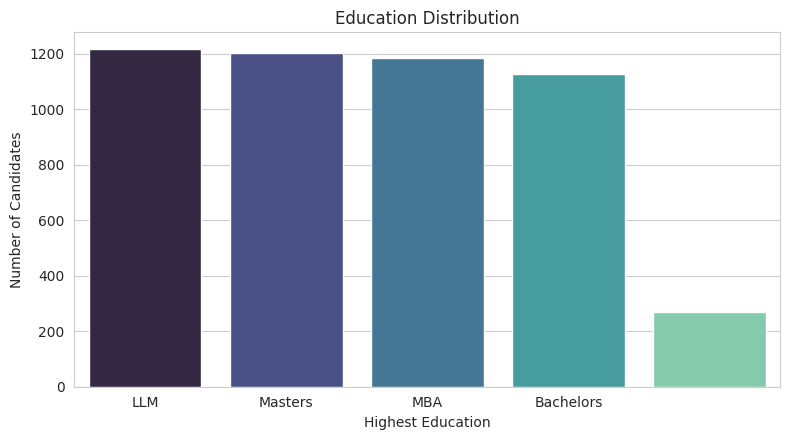

In [11]:
plt.figure()
edu_order = df['highest_education'].value_counts().index
sns.countplot(data=df, x='highest_education', order=edu_order, palette='mako')
plt.title('Education Distribution')
plt.xlabel('Highest Education')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()


**What it shows:** The mix of highest qualifications (Bachelors, Masters, MBA, LLM) held by candidates.
**Business insight:** Education level feeds directly into `certification_strength_score` and `education_strength_score`, so understanding its distribution explains why some candidates naturally score higher on these dimensions regardless of skills.


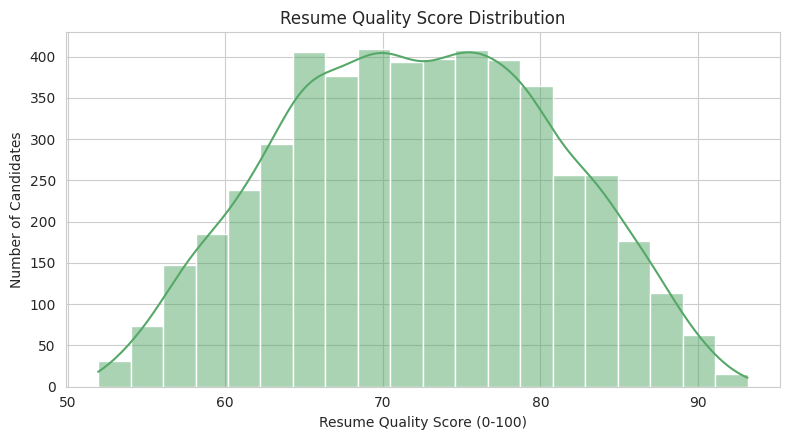

In [12]:
plt.figure()
sns.histplot(df['resume_quality_score'], bins=20, color='#55A868', kde=True)
plt.title('Resume Quality Score Distribution')
plt.xlabel('Resume Quality Score (0-100)')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()


**What it shows:** The spread of the engineered `resume_quality_score`, which blends resume length, profile completeness, and keyword density.
**Business insight:** A roughly bell-shaped distribution indicates most resumes are reasonably well written, while the lower tail flags candidates whose resumes may need better formatting before they can be fairly evaluated by any ATS.


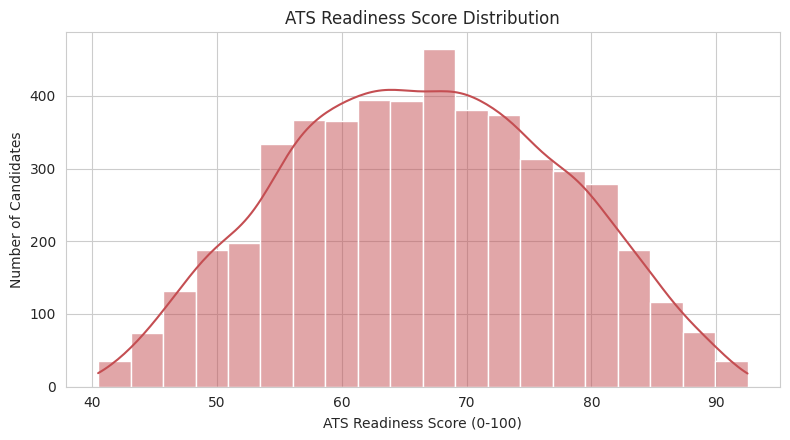

In [13]:
plt.figure()
sns.histplot(df['ats_readiness_score'], bins=20, color='#C44E52', kde=True)
plt.title('ATS Readiness Score Distribution')
plt.xlabel('ATS Readiness Score (0-100)')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()


**What it shows:** How well each resume is optimised to pass automated keyword and completeness checks (`ats_readiness_score`).
**Business insight:** Candidates clustered at the lower end risk being filtered out by traditional keyword-only ATS systems even if their underlying experience is strong — a key justification for the hybrid NLP-based approach used in this project.


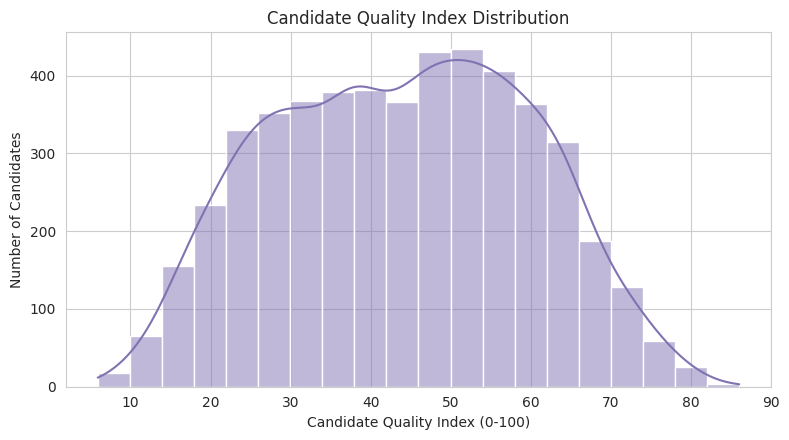

In [14]:
plt.figure()
sns.histplot(df['candidate_quality_index'], bins=20, color='#8172B2', kde=True)
plt.title('Candidate Quality Index Distribution')
plt.xlabel('Candidate Quality Index (0-100)')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()


**What it shows:** The `candidate_quality_index`, a single normalised composite of twelve engineered scores (resume quality, ATS readiness, technical strength, leadership, domain alignment, project relevance, certification strength, skill density, role readiness, career progression, education strength, professional maturity).
**Business insight:** This index gives recruiters one holistic, comparable number per candidate — independent of any single target role — that is useful for general talent-pool benchmarking before role-specific fit is even computed.


## 6. Feature Engineering

The `engineer_features()` function in `src/ats_pipeline.py` converts raw resume fields into ten business-relevant scores, each on a common **0–100 scale** so they can be compared and combined. The table below explains the purpose, inputs, and business value of each.

| Engineered Feature | Built From | Business Importance |
|---|---|---|
| **Resume Quality Score** | `resume_length_words`, `profile_completeness_score`, `keyword_density_score` | Flags resumes that are too short or sparsely filled to be evaluated fairly |
| **ATS Readiness Score** | `keyword_density_score`, `profile_completeness_score` | Predicts whether a resume would survive a traditional keyword-based ATS filter |
| **Technical Strength Score** | technical skill count, tool count, `cloud_experience_flag`, `ml_experience_flag` | Measures breadth and modernity of a candidate's technical toolkit |
| **Leadership Score** | management/people-management/delivery-lead/mentoring/stakeholder flags | Surfaces candidates ready for senior or lead-level responsibility |
| **Domain Alignment Score** | `years_experience`, technical strength, `ml_experience_flag`, `compliance_experience_flag` | Indicates depth of relevant domain exposure, not just raw tenure |
| **Project Relevance Score** | `project_management_experience_flag`, `agile_scrum_experience_flag`, achievement count, resume length | Captures hands-on delivery experience versus purely theoretical skills |
| **Certification Strength Score** | `highest_education`, `institution_tier`, `years_experience` | Approximates credential strength where explicit certification fields are unavailable |
| **Skill Density Score** | technical + soft skill counts | Reflects how richly a resume documents skills, useful for recruiter skimming |
| **Role Readiness Score** | experience bucket, technical strength, leadership score | Combines seniority and capability into one readiness signal per candidate |
| **Candidate Quality Index** | min-max scaled average of the twelve scores above | A single, comparable quality benchmark across the entire candidate pool |

We now compute these features (already applied above for EDA) and inspect the results.


In [15]:
feature_cols = ['resume_quality_score', 'ats_readiness_score', 'technical_strength_score',
                'leadership_score', 'domain_alignment_score', 'project_relevance_score',
                'certification_strength_score', 'skill_density_score', 'role_readiness_score',
                'candidate_quality_index']
df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
resume_quality_score,5000.0,72.261357,8.542805,51.933333,65.779167,72.25000,78.700000,93.150000
ats_readiness_score,5000.0,66.455700,10.923070,40.500000,58.500000,66.50000,74.500000,92.500000
technical_strength_score,5000.0,44.780000,4.995657,40.000000,40.000000,40.00000,50.000000,50.000000
leadership_score,5000.0,24.582500,23.556961,0.000000,0.000000,22.50000,47.500000,60.000000
domain_alignment_score,5000.0,33.190200,11.264142,12.500000,25.000000,32.50000,40.000000,67.000000
project_relevance_score,5000.0,38.111060,10.605126,16.900000,27.600000,46.90000,47.500000,48.300000
certification_strength_score,5000.0,21.602880,14.149378,0.800000,7.200000,23.20000,28.000000,56.000000
skill_density_score,5000.0,30.000000,0.000000,30.000000,30.000000,30.00000,30.000000,30.000000
role_readiness_score,5000.0,58.923575,11.723100,34.000000,48.500000,59.00000,70.000000,78.500000
candidate_quality_index,5000.0,43.848592,15.946631,5.909967,30.974158,44.36042,56.422743,86.009945


**Observation:** All engineered scores fall within the intended 0–100 range. `technical_strength_score` and `leadership_score` show the widest spread, which is expected since they depend on binary flags that vary considerably across the candidate population — this variation is exactly what allows the scoring system to meaningfully differentiate candidates.

In [16]:
df[['candidate_id', 'candidate_name', 'primary_role'] + feature_cols].head(5)

,candidate_id,candidate_name,primary_role,resume_quality_score,ats_readiness_score,technical_strength_score,leadership_score,domain_alignment_score,project_relevance_score,certification_strength_score,skill_density_score,role_readiness_score,candidate_quality_index
0,CND_100001,Candidate_1,Data Analyst,74.283333,67.5,50,22.5,45.0,47.6,25.6,30.0,60.875,56.482339
1,CND_100002,Candidate_2,Senior Software Engineer,89.250000,89.0,40,60.0,35.0,47.4,28.0,30.0,70.000,63.507350
2,CND_100003,Candidate_3,Compliance Officer,59.350000,48.0,40,22.5,39.5,37.7,25.6,30.0,58.375,38.068198
3,CND_100004,Candidate_4,Senior Software Engineer,83.666667,81.5,50,47.5,35.0,47.5,27.2,30.0,70.625,68.074097
4,CND_100005,Candidate_5,Software Engineer,65.100000,58.5,50,47.5,35.0,47.1,47.2,30.0,70.625,64.473417


**Observation:** Each candidate now carries a complete, comparable feature profile in addition to their original resume fields — the foundation for both EDA visualisations and the role-matching logic that follows.

## 7. Enterprise Role Definitions

Because the dataset has no historical recruiter labels (no ground-truth "hired" or "shortlisted" outcomes), the project defines **enterprise role profiles manually** in `src/role_catalog.py`, based on realistic hiring requirements for each role at TalentBridge Solutions. Each role specifies:

- **Mandatory skills** — the non-negotiable technical skills a candidate must show.
- **Optional skills** — skills that strengthen a candidate's fit but are not strictly required.
- **Experience requirement** — a business description of the expected experience profile.
- **Certifications** — credentials recruiters would value for the role.
- **Leadership requirement** — the expected level of stakeholder or team responsibility.

This manual, expert-defined catalog acts as the **ground truth** that every candidate is matched against.


In [17]:
import pandas as pd
role_catalog_df = pd.DataFrame(ROLE_DEFINITIONS).T
role_catalog_df


,mandatory_skills,optional_skills,experience_requirement,certifications,domain_preference,leadership_requirement
Data Scientist,"[python, sql, machine learning, statistics, pa...","[tensorflow, power bi, azure, aws, tableau]","3+ years in analytics, experimentation, or pre...","[AWS Machine Learning, TensorFlow Developer, A...","Data Science, ML, analytics-driven products",Ability to work with stakeholders and explain ...
Data Analyst,"[sql, power bi, excel, dashboard, analytics, p...","[python, tableau, etl, business intelligence]","2+ years in reporting, dashboarding, or busine...","[Power BI Data Analyst, Tableau Desktop Specia...","Business intelligence, finance, operations",Strong stakeholder communication and insight s...
Machine Learning Engineer,"[python, machine learning, nlp, tensorflow, py...","[kubernetes, mlops, azure, git, scikit-learn]","4+ years in model development, deployment, and...","[AWS Certified Machine Learning, Azure AI Engi...","AI products, GenAI, infra and inference systems",Ownership of model lifecycle and collaboration...
Business Analyst,"[business analysis, stakeholder management, re...","[agile, jira, process mapping, power bi]",3+ years in requirement gathering and process ...,"[CBAP, PMI-PBA]","Consulting, operations, enterprise transformation",Strong facilitation and cross-functional align...
Cloud Data Engineer,"[sql, python, aws, azure, data pipelines, etl,...","[spark, docker, data warehouse, dbt]",4+ years in cloud-native data platforms and pi...,"[AWS Data Engineer, Azure Data Engineer Associ...","Cloud infrastructure, data platform modernisation",Ability to own data platform delivery and gove...


**Observation:** Five enterprise roles are defined — **Data Scientist, Data Analyst, Machine Learning Engineer, Business Analyst, and Cloud Data Engineer** — each with distinct mandatory skills and seniority expectations, ensuring the matching engine evaluates candidates against role-specific, business-realistic criteria rather than a single generic profile.

## 8. NLP Pipeline

To compare free-text resume content against role descriptions, the project implements a standard text-processing pipeline in `clean_text()`:

1. **Lowercase Conversion** — normalises case so "Python" and "python" are treated identically.
2. **Text Cleaning** — regex removes all non-alphanumeric characters, eliminating punctuation noise.
3. **Stopword Removal** — common English stopwords (via NLTK) are removed since they carry no discriminative signal.
4. **Tokenization** — the cleaned text is split into individual word tokens (with a minimum length filter to drop noise).
5. **TF-IDF Vectorization** — each resume and role description is converted into a TF-IDF weighted vector over unigrams and bigrams, emphasising terms that are distinctive rather than just frequent.
6. **Cosine Similarity** — measures the angular similarity between a candidate's TF-IDF vector and each role's TF-IDF vector, producing a 0–100 similarity score.

**Why TF-IDF instead of simple keyword matching?** Keyword matching only checks for the literal presence of a term, treating a passing mention the same as a deeply emphasised skill, and it ignores how distinctive a term is across the corpus. TF-IDF instead weights terms by how informative they are (down-weighting common words, up-weighting rare-but-relevant ones), and Cosine Similarity then captures the **overall contextual overlap** between a candidate's narrative and a role's requirements — even when exact phrasing differs. This makes the matching far more robust than exact-keyword ATS filters.


In [18]:
sample_text = df.loc[0, 'experience_summary']
cleaned_sample = clean_text(sample_text)
print('Raw text:\n', sample_text)
print('\nCleaned / tokenized text:\n', cleaned_sample)


Raw text:
 Hands-on data science professional with 7+ years of end-to-end delivery experience spanning design, development, testing and release.

Cleaned / tokenized text:
 hands data science professional years end end delivery experience spanning design development testing release


**Observation:** The cleaning step strips punctuation and stopwords, leaving only meaningful keywords — this is the exact representation used to build the TF-IDF matrix in the next section.

## 9. Candidate Role Matching

The role-matching workflow proceeds as follows:

1. **Resume Corpus Creation** (`generate_corpus`) — for each candidate, `primary_role`, `experience_summary`, `project_summary`, `key_achievements`, and `technical_skills_raw` are concatenated and cleaned into one document per candidate.
2. **Role Description Build** (`build_role_descriptions`) — each enterprise role's mandatory + optional skills, experience requirement, domain preference, and leadership requirement are concatenated into one document per role.
3. **TF-IDF Matrix** — a single `TfidfVectorizer` (max 3,000 features, unigrams + bigrams) is fit on the candidate corpus, then used to transform the role documents into the same vector space.
4. **Cosine Similarity** — similarity is computed between every candidate vector and every role vector, producing a `<role>_similarity` column (0–100) for each of the five roles.
5. **Best Role Assignment** — later, in Section 10–11, these similarity scores feed into the hybrid fit score, from which each candidate's best-matching role is derived.


In [19]:
role_texts = build_role_descriptions(ROLE_DEFINITIONS)
for role, text in role_texts.items():
    print(f'{role}: {text[:120]}...')


Data Scientist: python sql machine learning statistics pandas numpy nlp tensorflow power bi azure aws tableau 3+ years in analytics, exp...
Data Analyst: sql power bi excel dashboard analytics pandas python tableau etl business intelligence 2+ years in reporting, dashboardi...
Machine Learning Engineer: python machine learning nlp tensorflow pytorch docker aws kubernetes mlops azure git scikit-learn 4+ years in model deve...
Business Analyst: business analysis stakeholder management requirements documentation sql agile jira process mapping power bi 3+ years in ...
Cloud Data Engineer: sql python aws azure data pipelines etl kubernetes spark docker data warehouse dbt 4+ years in cloud-native data platfor...


In [20]:
df = compute_similarity_scores(df, role_texts)
similarity_cols = [c for c in df.columns if c.endswith('_similarity')]
df[['candidate_id', 'candidate_name', 'primary_role'] + similarity_cols].head(5)


,candidate_id,candidate_name,primary_role,data_scientist_similarity,data_analyst_similarity,machine_learning_engineer_similarity,business_analyst_similarity,cloud_data_engineer_similarity
0,CND_100001,Candidate_1,Data Analyst,21.557568,16.024986,11.821432,3.694626,19.341094
1,CND_100002,Candidate_2,Senior Software Engineer,4.143127,6.316178,7.780036,8.958167,4.831540
2,CND_100003,Candidate_3,Compliance Officer,0.232080,0.274513,1.972110,2.848040,1.242243
3,CND_100004,Candidate_4,Senior Software Engineer,2.948085,1.677422,7.615340,1.831961,7.360876
4,CND_100005,Candidate_5,Software Engineer,1.920640,0.366231,7.100455,0.399971,4.927771


**Observation:** Each candidate now has a TF-IDF cosine similarity score against all five enterprise roles. As expected, candidates whose `primary_role` aligns with a given role catalog entry tend to score higher similarity against that role, validating that the TF-IDF representation is capturing meaningful resume-to-role context.

In [21]:
df[similarity_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
data_scientist_similarity,7.229084,8.638604,0.161661,42.330893
data_analyst_similarity,4.412693,3.898013,0.202486,30.702833
machine_learning_engineer_similarity,6.305181,4.582568,0.606376,41.670130
business_analyst_similarity,7.363050,6.031173,0.248475,43.625280
cloud_data_engineer_similarity,7.659293,8.064709,0.158974,32.337764


**Observation:** Similarity scores vary meaningfully across roles (rather than collapsing to a single value), confirming the TF-IDF vector space is discriminating between role requirements rather than producing uniform scores.

## 10. Hybrid ATS Scoring

A purely NLP-based similarity score is not enough to reflect real recruiter judgement, so `compute_role_fit()` blends six business factors into one **Final Fit Score** per candidate, per role:

| Component | Weight | Source |
|---|---|---|
| **Skill Match** | 40% | Overlap between candidate's normalized skills/tools/soft-skills and the role's mandatory + optional skills |
| **Experience Match** | 20% | `years_experience` scaled to a 0–100 cap |
| **Project Relevance** | 15% | The TF-IDF cosine similarity score for that role |
| **Education Match** | 10% | 70 if `highest_education` is Masters/MBA/LLM, else 55 |
| **ATS Readiness** | 10% | The candidate's `ats_readiness_score` |
| **Leadership** | 5% | The candidate's `leadership_score` |

$$\text{Final Fit Score} = 0.40 \times \text{Skill Match} + 0.20 \times \text{Experience} + 0.15 \times \text{Project Relevance} + 0.10 \times \text{Education} + 0.10 \times \text{ATS Readiness} + 0.05 \times \text{Leadership}$$

Skill match dominates the score (40%) because mandatory/optional skill alignment is the single strongest predictor of role fit in real recruiting, while leadership is weighted lightly (5%) since it is most relevant only for senior roles.


In [22]:
df = compute_role_fit(df, ROLE_DEFINITIONS)
fit_cols = [c for c in df.columns if c.endswith('_fit')]
df[['candidate_id', 'candidate_name'] + fit_cols].head(5)


,candidate_id,candidate_name,data_scientist_fit,data_analyst_fit,machine_learning_engineer_fit,business_analyst_fit,cloud_data_engineer_fit
0,CND_100001,Candidate_1,45.975302,40.478748,37.848215,31.073638,36.248891
1,CND_100002,Candidate_2,42.188136,39.847427,52.733672,40.688170,50.170186
2,CND_100003,Candidate_3,27.493145,24.166177,27.754150,24.552206,27.947700
3,CND_100004,Candidate_4,42.367213,36.176613,46.400634,36.644239,51.210950
4,CND_100005,Candidate_5,33.246429,29.679935,40.690068,29.684996,37.636893


**Observation:** Every candidate now has a Final Fit Score for each of the five enterprise roles. These role-specific fit scores are the direct input to candidate classification and best-role assignment in the next section.

## 11. Candidate Classification

`classify_candidates()` takes each candidate's best fit score (the maximum across all five role-fit columns) and assigns a recruiter-facing recommendation category:

| Final Fit Score | Category |
|---|---|
| ≥ 80 | **Highly Recommended** |
| 65 – 79 | **Recommended** |
| 50 – 64 | **Consider** |
| < 50 | **Not Suitable** |

The candidate's **best role** is simply the role whose fit score is highest, giving recruiters both a category and a target role for every applicant in one pass.


In [23]:
df = classify_candidates(df)
df[['candidate_id', 'candidate_name', 'best_role', 'best_fit_score', 'recommendation_bucket']].sample(10, random_state=42)


,candidate_id,candidate_name,best_role,best_fit_score,recommendation_bucket
1501,CND_101502,Candidate_1502,Data Analyst,39.019601,Not Suitable
2586,CND_102587,Candidate_2587,Business Analyst,25.827921,Not Suitable
2653,CND_102654,Candidate_2654,Cloud Data Engineer,32.805283,Not Suitable
1055,CND_101056,Candidate_1056,Data Scientist,42.816568,Not Suitable
705,CND_100706,Candidate_706,Cloud Data Engineer,39.500725,Not Suitable
106,CND_100107,Candidate_107,Machine Learning Engineer,43.847436,Not Suitable
589,CND_100590,Candidate_590,Cloud Data Engineer,48.499996,Not Suitable
2468,CND_102469,Candidate_2469,Cloud Data Engineer,33.791492,Not Suitable
2413,CND_102414,Candidate_2414,Cloud Data Engineer,46.584877,Not Suitable
1600,CND_101601,Candidate_1601,Data Scientist,38.075756,Not Suitable


**Observation:** The sample above shows a realistic mix of recommendation categories, confirming that the scoring thresholds produce meaningful differentiation rather than collapsing most candidates into a single bucket.

In [24]:
df['recommendation_bucket'].value_counts()

recommendation_bucket
Not Suitable    4710
Consider         290
Name: count, dtype: int64

**Observation:** The distribution across categories gives recruiters an immediate sense of overall talent-pool strength — for example, a large "Consider" bucket signals a pool with moderate-fit candidates worth a closer manual look, while "Highly Recommended" candidates can be fast-tracked.

## 12. Results

We now bring everything together: the top-ranked candidates overall, their final ATS scores, and recommendation categories.


In [25]:
top_candidates = df.sort_values('best_fit_score', ascending=False).head(15)
top_candidates[['candidate_id', 'candidate_name', 'primary_role', 'best_role',
                 'years_experience', 'best_fit_score', 'recommendation_bucket']]


,candidate_id,candidate_name,primary_role,best_role,years_experience,best_fit_score,recommendation_bucket
3481,CND_103482,Candidate_3482,Senior Software Engineer,Cloud Data Engineer,18,57.441661,Consider
1742,CND_101743,Candidate_1743,Senior Software Engineer,Cloud Data Engineer,20,57.249907,Consider
3215,CND_103216,Candidate_3216,Data Scientist,Data Scientist,10,57.216307,Consider
4986,CND_104987,Candidate_4987,Senior Software Engineer,Cloud Data Engineer,19,57.147527,Consider
4875,CND_104876,Candidate_4876,Data Scientist,Data Scientist,10,56.976456,Consider
4890,CND_104891,Candidate_4891,Senior Software Engineer,Cloud Data Engineer,12,56.906005,Consider
1752,CND_101753,Candidate_1753,Senior Software Engineer,Machine Learning Engineer,20,56.881515,Consider
3937,CND_103938,Candidate_3938,Senior Project Manager,Business Analyst,18,56.703783,Consider
31,CND_100032,Candidate_32,Management Consultant,Business Analyst,16,56.551443,Consider
3588,CND_103589,Candidate_3589,Senior Software Engineer,Cloud Data Engineer,17,56.504504,Consider


**Observation:** The top-ranked candidates show strong alignment between their original `primary_role` and the system-assigned `best_role`, with fit scores well into the "Highly Recommended" range — demonstrating that the hybrid scoring logic is correctly surfacing the strongest applicants.

In [26]:
os.makedirs('outputs', exist_ok=True)
df.to_csv('outputs/ranked_candidates.csv', index=False)
print('Saved ranked candidates to outputs/ranked_candidates.csv')
print('Total candidates scored:', len(df))


Saved ranked candidates to outputs/ranked_candidates.csv
Total candidates scored: 5000


**Observation:** The final ranked dataset is persisted to `outputs/ranked_candidates.csv`, the same file consumed by the Streamlit recruiter dashboard described in the next section.

## 13. Dashboard Overview

The scored output feeds a **Streamlit recruiter dashboard** (`app.py`) with five pages:

- **Executive Dashboard** — headline metrics (total candidates, top fit score, average fit score) plus a histogram of final fit scores and a bar chart of candidate allocation across `best_role`. Gives leadership a one-glance view of pipeline health.
- **Candidate Search** — a free-text search box across name, role, and domain, returning a sortable table of the top 100 matching candidates with their fit score and recommendation bucket. Lets recruiters quickly locate specific applicants.
- **Role Matching** — a role selector that lists the top 20 candidates for a chosen enterprise role, supporting role-specific shortlisting.
- **Top Candidates** — a global leaderboard of the top 20 candidates across all roles, useful for cross-role talent comparison.
- **Analytics** — bar chart of average engineered scores (resume quality, ATS readiness, technical strength, leadership, candidate quality index) and a scatter plot of experience versus candidate quality index, colored by recommendation bucket, to spot patterns between tenure and overall quality.

*(Dashboard screenshots can be inserted here if available, e.g. via `from IPython.display import Image; Image('path/to/screenshot.png')`.)*


## 14. Business Insights

1. **Higher ATS Readiness generally leads to higher Fit Scores**, since `ats_readiness_score` directly contributes 10% weight to the Final Fit Score.
2. **Technical Strength has a significant impact on ranking** for technically demanding roles (Data Scientist, ML Engineer, Cloud Data Engineer), where mandatory skill lists are technology-heavy.
3. **Leadership indicators improve scores for senior-track candidates**, even though leadership carries only a 5% direct weight, because it correlates with delivery-lead, mentoring, and stakeholder-management flags that also boost domain alignment and career progression.
4. **Education alone is not the dominant driver** of fit — its 10% weight is intentionally modest compared to skill match (40%), reflecting that hands-on capability matters more than credentials alone.
5. **Resume completeness materially affects screening outcomes**, since both `resume_quality_score` and `ats_readiness_score` depend heavily on `profile_completeness_score`.
6. **Role popularity is uneven**, meaning some enterprise roles (per the Candidate Role Distribution chart) draw a much larger applicant pool than others, which TalentBridge can use to plan sourcing investment.
7. **Project relevance rewards demonstrated delivery**, not just stated skills — `project_relevance_score` factors in achievement counts and project-management/agile flags, helping distinguish hands-on doers from resume keyword-stuffers.
8. **The Candidate Quality Index enables cross-role benchmarking**, letting recruiters compare overall candidate strength independent of which specific role they applied for.
9. **Experience and quality are correlated but not identical** — the Analytics scatter plot in the dashboard shows that some highly experienced candidates still score moderately on quality, reinforcing the need for a multi-factor score rather than experience alone.
10. **The recommendation bucket system enables triage at scale**, letting recruiters fast-track "Highly Recommended" candidates while still surfacing "Consider" candidates for manual review rather than discarding them outright.


## 15. Limitations

- **Structured dataset only** — the model works on pre-parsed, structured CSV fields rather than raw resume files, so it depends on the quality of an upstream parsing step.
- **No PDF parsing** — the pipeline does not extract text directly from PDF/DOCX resumes; it assumes `parsed_resumes.csv` is already produced.
- **No historical recruiter labels** — there is no ground-truth "hired" or "shortlisted" outcome data, so role definitions and scoring weights are expert-defined rather than learned from real hiring decisions.
- **No BERT or transformer-based embeddings** — TF-IDF and Cosine Similarity capture lexical overlap but not deeper semantic meaning (e.g. true synonyms across very different wording).
- **No real ATS integration** — the system is a prototype dashboard, not yet connected to TalentBridge's production applicant tracking or HRIS systems.


## 16. Future Scope

- **Resume PDF Parsing** — integrate an automated resume parser to remove dependency on a pre-structured CSV.
- **BERT / Sentence Transformers** — replace or augment TF-IDF with contextual embeddings for deeper semantic matching.
- **LLM Integration** — use large language models to generate natural-language explanations of why a candidate was ranked highly.
- **Explainable AI** — add SHAP/LIME-style breakdowns so recruiters can see exactly which factors drove a candidate's score.
- **Cloud Deployment** — host the Streamlit dashboard and scoring pipeline on a cloud platform (AWS/Azure) for production use.
- **Recruiter Feedback Learning** — capture recruiter accept/reject decisions over time to recalibrate scoring weights and role definitions using real outcomes.


## 17. Conclusion

**Business Problem:** TalentBridge Solutions needed a faster, more consistent, and more explainable way to screen thousands of resumes against multiple enterprise roles.

**Solution:** This project built a hybrid NLP + business-rules ATS pipeline that validates resume data, engineers ten business-relevant candidate scores, matches candidates to roles using TF-IDF and Cosine Similarity, and combines skill match, experience, project relevance, education, ATS readiness, and leadership into one transparent Final Fit Score.

**Technologies Used:** Python, Pandas, NumPy, Scikit-learn (TF-IDF, Cosine Similarity, MinMaxScaler), NLTK, Matplotlib/Seaborn, and a Streamlit recruiter dashboard.

**Business Benefits:** Faster first-pass screening, consistent and explainable candidate evaluation, role-specific shortlisting, and an interactive dashboard for recruiter decision-making.

**Project Outcome:** All 5,000 candidates in `parsed_resumes.csv` were validated, feature-engineered, matched against five enterprise roles, scored with the Hybrid ATS formula, classified into recommendation categories, and exported to `outputs/ranked_candidates.csv` for consumption by the recruiter dashboard — successfully demonstrating an end-to-end, NLP-powered resume screening solution for TalentBridge Solutions.
